# Multi-temporal RGB over shaded relief: Clear Lake (California)

This case study explores a spring time series of GRS L2A images over Clear Lake (California, USA),
a large shallow eutrophic lake surrounded by mountains, subject to recurrent cyanobacteria blooms.

**Workflow**

1. build the L2A datacube over the lake from the Sentinel-2 tiles ({class}`grstbx.L2grs`),
2. check the availability of valid water pixels and the cloud cover of each image,
3. display the water-leaving reflectance as RGB composites over the shaded relief computed from
   the DEM for the sun position of each acquisition ({meth}`grstbx.Dem.compute_dem_attributes`):
   the terrain shadows, which can bias the retrievals near the shores, are directly visible,
4. inspect the pixel classification flags ({class}`grstbx.Masking`),
5. extract the $R_{rs}$ spectra of an area of the lake for each date.

**Data**: GRS L2A products (20 m) of the Sentinel-2 tile 10SEJ, April-May 2024. They are not
distributed with grstbx: set the paths of the configuration cell to your own files to run the
notebook.

## Libraries and configuration

In [1]:
import glob
import os
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray  # activate the rio accessor
import cartopy.crs as ccrs
import matplotlib as mpl
import matplotlib.pyplot as plt

import grstbx

opj = os.path.join

plt.rcParams.update({'font.family': 'serif', 'mathtext.fontset': 'stix',
                     'font.size': 13, 'axes.labelsize': 14,
                     'figure.dpi': 80})

print(f'grstbx: {grstbx.__version__}')

grstbx: 2.1.1


In [2]:
L2A_DIR = '/data/satellite/Sentinel-2/L2A'
TILE = '10SEJ'
START_DATE, END_DATE = '2024-01-01', '2024-12-31'

# area of interest (lon/lat): Clear Lake
LONMIN, LATMIN, LONMAX, LATMAX = -122.925, 38.91, -122.61, 39.14

# area within the lake used to extract the spectra (lon/lat)
SPECTRA_BOX = (-122.86, 39.05, -122.82, 39.08)

RGB_BANDS = [705, 560, 490]   # red-edge band to highlight the phytoplankton
RELIEF_Z_FACTOR = 3           # vertical exaggeration of the shaded relief (display only)
FIGDIR = None                 # directory to save the figures, None: not saved

## Datacube

The L2A products are stored as `L2A_DIR/TILE/YYYY/MM/DD/<product>/`. The images are cropped to the
area of interest and concatenated along time; the proportion of pixels raised for each flag is
added for each image as `flag_<name>` variables.

The cropped images are loaded in memory: for the 22 images of this example (about
1150 x 1300 pixels and 11 bands), about 20 GB of RAM are used while building the datacube. Reduce
the area or the period if needed.

In [3]:
def list_grs_products(rootdir, site, pattern='*'):
    """
    List the GRS products stored as ``rootdir/site/YYYY/MM/DD/<product>``.

    The product names follow the ESA convention
    ``<satellite>_<level>_<time>_<baseline>_<orbit>_<tile>_<processing time>``.

    :return: pandas.DataFrame indexed (and sorted) by acquisition time, with the path of each product
    """
    paths = sorted(glob.glob(opj(rootdir, site, '*', '*', '*', pattern)))
    if not paths:
        raise FileNotFoundError(f'no product found in {opj(rootdir, site)}')
    names = pd.Series([os.path.basename(p) for p in paths])
    products = names.str.split('_', expand=True).iloc[:, :7]
    products.columns = ['satellite', 'level', 'time', 'baseline', 'orbit', 'tile', 'processing_time']
    products['time'] = pd.to_datetime(products['time'])
    products['path'] = paths
    return products.set_index('time').sort_index()

In [4]:
products = list_grs_products(L2A_DIR, TILE, pattern='*L2A*')
files = products[START_DATE:END_DATE].path.values
print(f'{len(files)} L2A products from {START_DATE} to {END_DATE}')
products

22 L2A products from 2024-01-01 to 2024-12-31


,satellite,level,baseline,orbit,tile,processing_time,path
time,,,,,,,
2024-04-01 18:59:29,S2B,MSIL2Agrs,N0510,R013,T10SEJ,20240401T223811,/data/satellite/Sentinel-2/L2A/10SEJ/2024/04/0...
2024-04-03 18:49:11,S2A,MSIL2Agrs,N0510,R113,T10SEJ,20240403T233904,/data/satellite/Sentinel-2/L2A/10SEJ/2024/04/0...
2024-04-06 18:59:11,S2A,MSIL2Agrs,N0510,R013,T10SEJ,20240406T234725,/data/satellite/Sentinel-2/L2A/10SEJ/2024/04/0...
2024-04-08 18:49:19,S2B,MSIL2Agrs,N0510,R113,T10SEJ,20240409T135916,/data/satellite/Sentinel-2/L2A/10SEJ/2024/04/0...
2024-04-11 18:59:19,S2B,MSIL2Agrs,N0510,R013,T10SEJ,20240411T223833,/data/satellite/Sentinel-2/L2A/10SEJ/2024/04/1...
2024-04-18 18:49:19,S2B,MSIL2Agrs,N0510,R113,T10SEJ,20240418T222858,/data/satellite/Sentinel-2/L2A/10SEJ/2024/04/1...
2024-04-21 18:59:19,S2B,MSIL2Agrs,N0510,R013,T10SEJ,20240421T210918,/data/satellite/Sentinel-2/L2A/10SEJ/2024/04/2...
2024-04-23 18:49:31,S2A,MSIL2Agrs,N0510,R113,T10SEJ,20240424T000533,/data/satellite/Sentinel-2/L2A/10SEJ/2024/04/2...
2024-04-26 18:59:21,S2A,MSIL2Agrs,N0510,R013,T10SEJ,20240427T001649,/data/satellite/Sentinel-2/L2A/10SEJ/2024/04/2...


In [5]:
from shapely.geometry import box

aoi = gpd.GeoDataFrame(geometry=[box(LONMIN, LATMIN, LONMAX, LATMAX)], crs=4326)
dc = grstbx.L2grs(files)
with warnings.catch_warnings():
    # the dask chunks of L2grs do not match the chunks stored in the netCDF files
    warnings.filterwarnings('ignore', message='The specified chunks separate the stored chunks')
    dc.get_l2a_datacube(subset=aoi)
datacube = dc.datacube.drop_duplicates('time')
datacube['Rrs'] = datacube.Rrs.astype(np.float32)   # stored as float64: halve the memory
datacube

<xarray.Dataset> Size: 4GB
Dimensions:                          (time: 22, wl: 11, y: 1279, x: 1367)
Coordinates:
  * wl                               (wl) int64 88B 443 490 560 ... 1610 2190
  * time                             (time) datetime64[ns] 176B 2024-04-01T18...
  * x                                (x) float64 11kB 5.065e+05 ... 5.338e+05
  * y                                (y) float64 10kB 4.332e+06 ... 4.307e+06
    central_wavelength               (time, wl) float32 968B 442.2 ... 2.186e+03
    band                             int64 8B 1
    spatial_ref                      int64 8B 0
Data variables: (12/23)
    Rrs                              (time, wl, y, x) float32 2GB nan ... nan
    BRDFg                            (time, y, x) float64 308MB nan nan ... nan
    aot550                           (time, y, x) float64 308MB 0.043 ... 0.066
    mask                             (time, y, x) uint8 38MB 1 1 1 1 ... 1 1 1 1
    vza                              (time, y, x) float64 308MB 6.75 ... 7.91
    sza                              (time, y, x) float64 308MB nan nan ... nan
    ...                               ...
    flag_opac_cirrus                 (time) float64 176B 1.087e-05 ... 0.1069
    flag_high_swir                   (time) float64 176B 0.00475 ... 0.05377
    flag_surfwater_land              (time) float64 176B 0.0 0.0 0.0 ... 0.0 0.0
    flag_surfwater_water             (time) float64 176B 1.0 1.0 1.0 ... 1.0 1.0
    flag_surfwater_cloud_and_shadow  (time) float64 176B 0.0 0.0 0.0 ... 0.0 0.0
    flag_neg_rrs                     (time) float64 176B 0.01272 ... 0.005337
Attributes: (12/74)
    long_name:                           CA BLUE GREEN RED VRE_1 VRE_2 VRE_3 ...
    constellation:                       Sentinel-2
    constellation_id:                    S2
    product_path:                        /data/satellite/Sentinel-2/L1C/10SEJ...
    product_name:                        S2B_MSIL1C_20240401T185929_N0510_R01...
    product_filename:                    S2B_MSIL1C_20240401T185929_N0510_R01...
    ...                                  ...
    dirdata:                             /data/grs/grsdata
    abs_gas_file:                        /home/harmel/Dropbox/Dropbox/work/gi...
    water_vapor_transmittance_file:      /home/harmel/Dropbox/Dropbox/work/gi...
    metadata_profile:                    datacube
    start_date:                          2024-04-01T18:59:29.000000000
    stop_date:                           2024-05-28T18:49:19.000000000

## Image quality

Proportion of the area flagged as cloud (s2cloudless, low and high confidence) and of valid water
pixels (`mask == 0`) for each image:

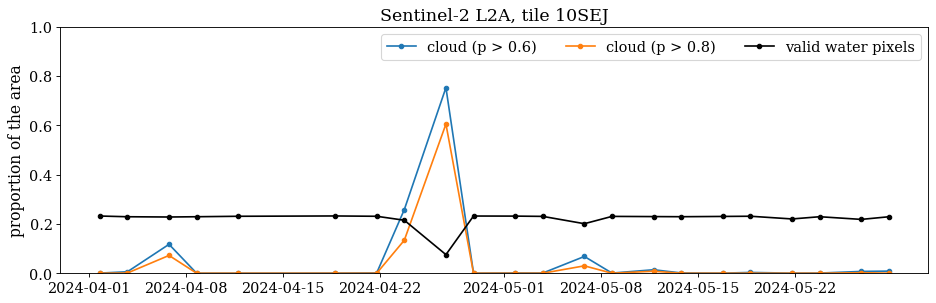

In [6]:
npix = datacube.sizes['x'] * datacube.sizes['y']
valid_fraction = (datacube.mask == 0).sum(['x', 'y']) / npix

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(datacube.time.values, datacube.flag_cloud_p06.values, 'o-', ms=4, label='cloud (p > 0.6)')
ax.plot(datacube.time.values, datacube.flag_cloud_p08.values, 'o-', ms=4, label='cloud (p > 0.8)')
ax.plot(datacube.time.values, valid_fraction.values, 'o-', ms=4, c='k', label='valid water pixels')
ax.set_ylabel('proportion of the area')
ax.set_ylim(0, 1)
ax.legend(ncols=3)
ax.set_title(f'Sentinel-2 L2A, tile {TILE}');

## Shaded relief

For each image, the slope and the cosine of the local solar incidence angle are computed from the
DEM stored in the L2A product and from the mean sun position of the acquisition:

$$\cos\theta_i = \cos\theta_s \cos\beta + \sin\theta_s \sin\beta \cos(\phi_s - \alpha)$$

with $\theta_s$ and $\phi_s$ the solar zenith and azimuth angles, $\beta$ the slope and $\alpha$
the aspect of the terrain (downslope direction, clockwise from North). Low values (dark) are poorly
illuminated, negative values are in the shadow of the relief. The background of the RGB composites
below uses a vertical exaggeration (`RELIEF_Z_FACTOR`) to enhance the relief.

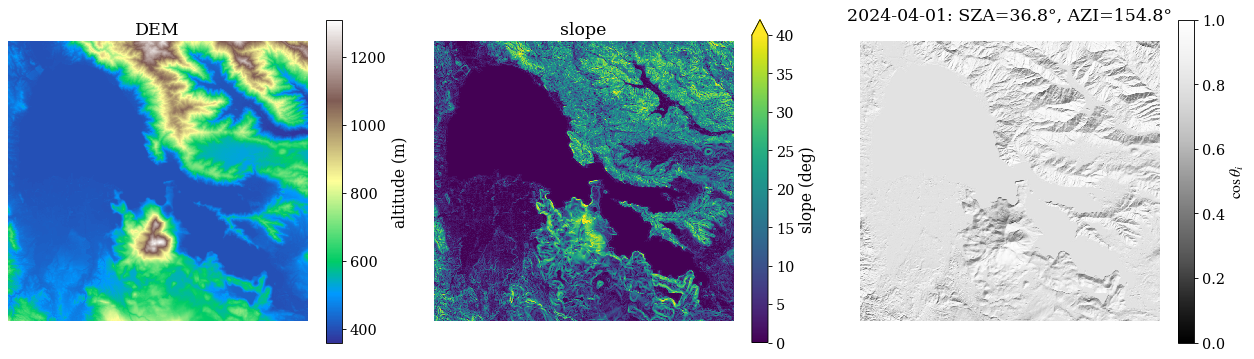

In [7]:
date = datacube.time[0]
raster = datacube.sel(time=date)
sza, azi = float(raster.mean_solar_zenith_angle), float(raster.mean_solar_azimuth)
relief = grstbx.Dem.compute_dem_attributes(datacube.dem, sza, azi)

fig, axs = plt.subplots(ncols=3, figsize=(16, 4.6))
datacube.dem.plot.imshow(ax=axs[0], cmap='terrain', cbar_kwargs={'label': 'altitude (m)'})
np.degrees(relief.slope).plot.imshow(ax=axs[1], vmin=0, vmax=40, cmap='viridis', cbar_kwargs={'label': 'slope (deg)'})
relief.shaded.plot.imshow(ax=axs[2], cmap='Greys_r', vmin=0, vmax=1, cbar_kwargs={'label': r'$\cos\theta_i$'})
axs[0].set_title('DEM')
axs[1].set_title('slope')
axs[2].set_title(f'{pd.Timestamp(date.values):%Y-%m-%d}: SZA={sza:.1f}°, AZI={azi:.1f}°')
for ax in axs:
    ax.set_aspect('equal')
    ax.set_axis_off()
fig.tight_layout()

## Time series of RGB composites

$R_{rs}$ of the valid water pixels at 705, 560 and 490 nm over the shaded relief of each date. The
705 nm band, sensitive to the phytoplankton biomass, makes the blooms appear in red.

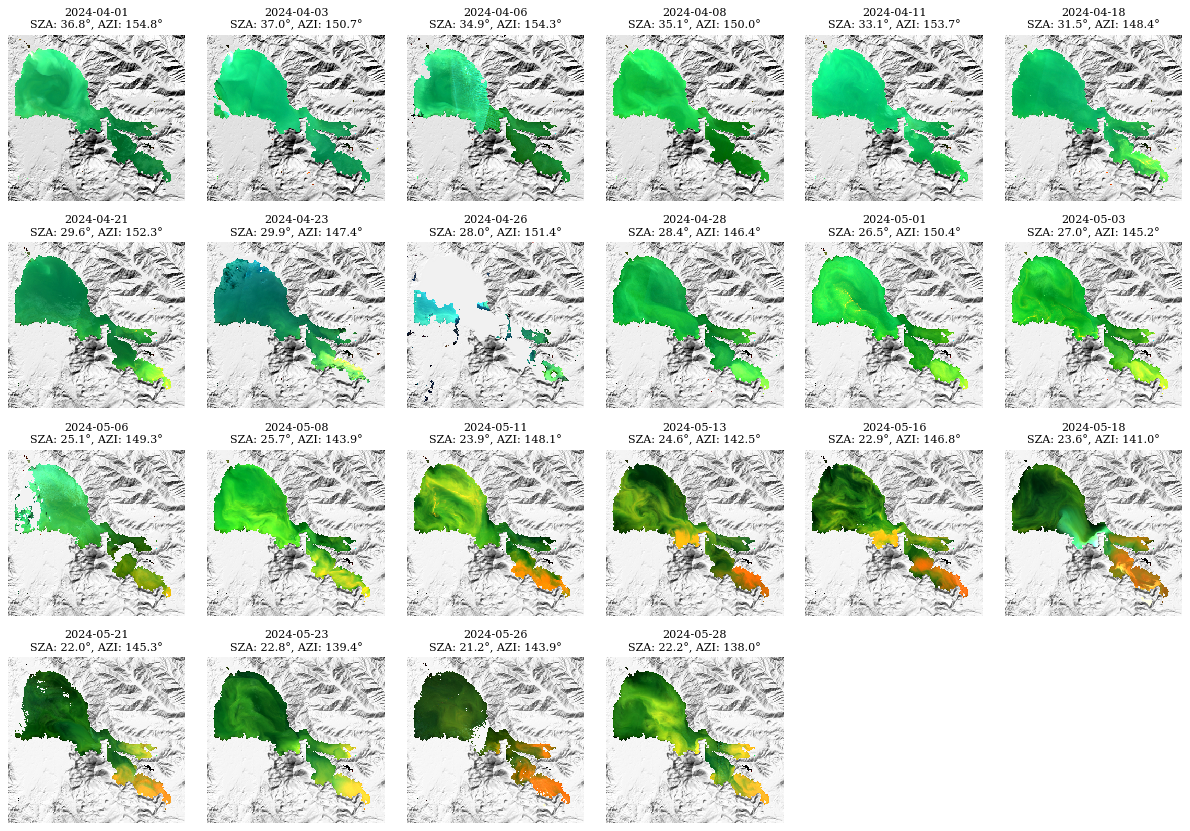

In [8]:
def plot_rgb_relief(datacube, dates, ncols=6, size=3.2, vmax=None, coarsen=4):
    """RGB composites of the water pixels over the shaded relief, one panel per date."""
    proj = ccrs.epsg(datacube.rio.crs.to_epsg())
    nrows = int(np.ceil(len(dates) / ncols))
    ncols = min(ncols, len(dates))
    fig, axs = plt.subplots(nrows, ncols, figsize=(ncols * size, nrows * size), squeeze=False,
                            subplot_kw={'projection': proj})
    fig.subplots_adjust(hspace=0.25, wspace=0.03)
    for ax in axs.flat:
        ax.set_axis_off()
    # coarsen the images for display only
    cube = datacube.coarsen(x=coarsen, y=coarsen, boundary='trim').mean() if coarsen > 1 else datacube
    for ax, date in zip(axs.flat, dates):
        raster = cube.sel(time=date)
        sza, azi = float(raster.mean_solar_zenith_angle), float(raster.mean_solar_azimuth)
        relief = grstbx.Dem.compute_dem_attributes(cube.dem, sza, azi, z_factor=RELIEF_Z_FACTOR)
        relief.shaded.plot.imshow(ax=ax, cmap='Greys_r', vmin=0, vmax=1, add_colorbar=False)
        rgb = raster.Rrs.sel(wl=RGB_BANDS).where(raster.mask == 0)
        rgb.plot.imshow(ax=ax, rgb='wl', robust=vmax is None, vmin=0 if vmax else None, vmax=vmax)
        ax.set_title(f'{pd.Timestamp(date):%Y-%m-%d}\nSZA: {sza:.1f}°, AZI: {azi:.1f}°', fontsize=10)
    return fig


fig = plot_rgb_relief(datacube, datacube.time.values)
if FIGDIR:
    fig.savefig(opj(FIGDIR, f'{TILE}_{START_DATE}_{END_DATE}_clear_lake.png'), bbox_inches='tight')

With `robust=True`, the color stretch is adapted to each image; a fixed range eases the comparison
between dates:

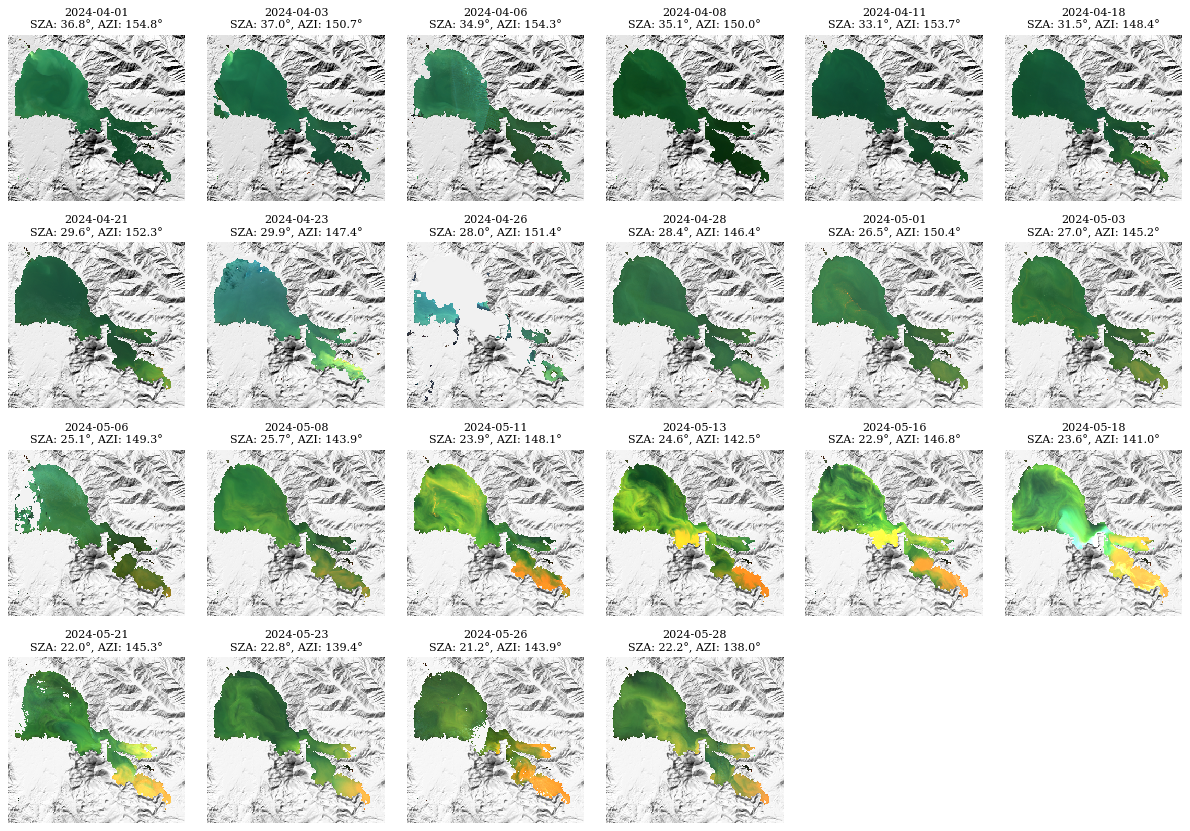

In [9]:
fig = plot_rgb_relief(datacube, datacube.time.values, vmax=0.025)

### Bloom development in mid-May

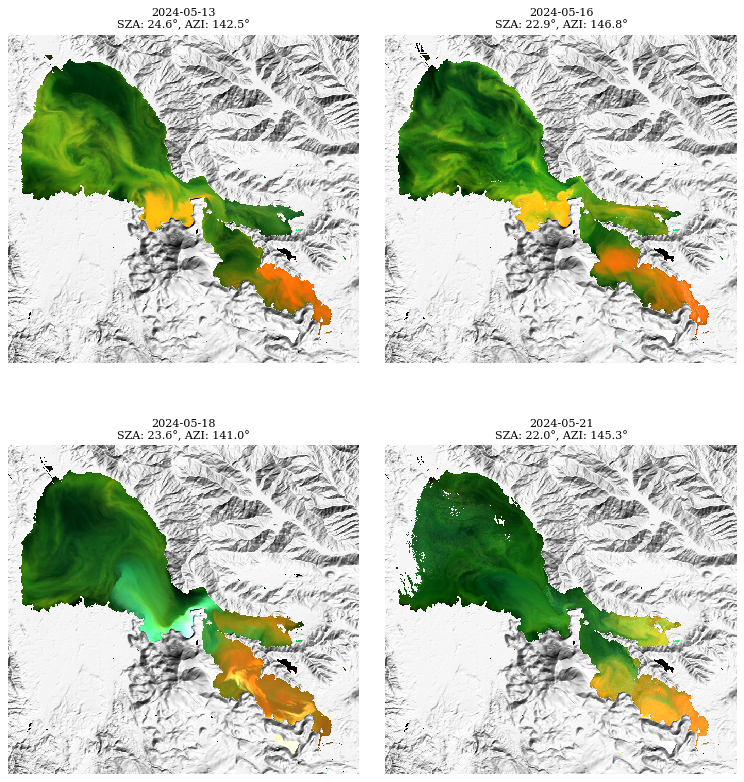

In [10]:
bloom_dates = datacube.sel(time=slice('2024-05-13', '2024-05-21')).time.values
fig = plot_rgb_relief(datacube, bloom_dates, ncols=2, size=6, coarsen=2)
if FIGDIR:
    fig.savefig(opj(FIGDIR, f'{TILE}_clear_lake_example_bloom.png'), dpi=300, bbox_inches='tight')

## Pixel classification

The GRS bitmask `flags` is decoded with {class}`grstbx.Masking`: list of the available flags and
overlay of the cloud masks on the true-color composite of one image.

In [11]:
date = bloom_dates[0]
raster = datacube.sel(time=date)
masking = grstbx.Masking(raster)
masking.print_info()

,description,bit,value
name,,,
nodata,nodata in input image,0,1
cloud_p06,low confidence cloud mask from s2cloudless wit...,1,2
cloud_p08,high confidence cloud mask from s2cloudless wi...,2,4
water_swir_visible_index,water mask from normalized index from swir and...,3,8
water_red_visible_index,water mask from normalized index from nir and ...,4,16
thin_cirrus,"thin cirrus mask from cirrus band, threshold 0...",5,32
opac_cirrus,"opac cirrus mask from cirrus band, threshold 0...",6,64
high_swir,"high swir (bright cloud, too bright reflection...",7,128
surfwater_land,land mask from surfwater input file,8,256


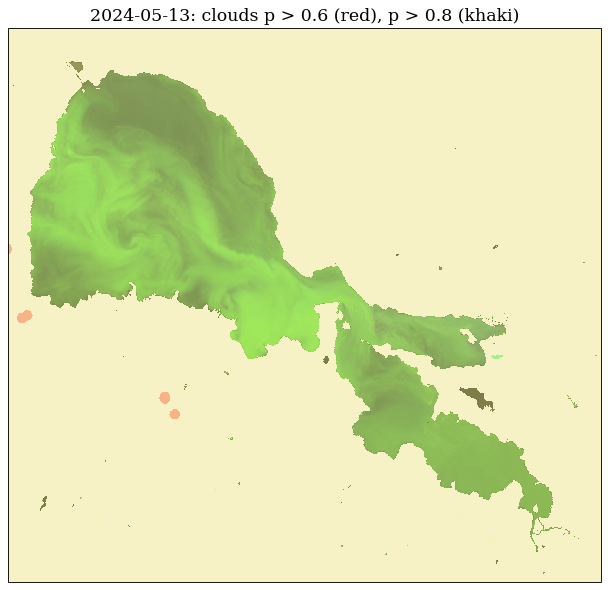

In [12]:
proj = ccrs.epsg(datacube.rio.crs.to_epsg())
fig, ax = plt.subplots(figsize=(10, 9), subplot_kw={'projection': proj})
rgb = raster.Rrs.sel(wl=[665, 560, 490]).where(raster.mask == 0)
rgb.where(raster.Rrs.sel(wl=560) < 0.075).plot.imshow(ax=ax, rgb='wl', vmin=0, vmax=0.025)
for flag, color in [('cloud_p06', 'red'), ('cloud_p08', 'khaki')]:
    flagged = masking.get_mask(**{flag: True})
    cmap = mpl.colors.ListedColormap([(0, 0, 0, 0), color])
    flagged.plot.imshow(ax=ax, cmap=cmap, alpha=0.5, add_colorbar=False)
ax.set_title(f'{pd.Timestamp(date):%Y-%m-%d}: clouds p > 0.6 (red), p > 0.8 (khaki)');

## Spectra of an area of the lake

$R_{rs}$ statistics (400-900 nm) of the valid pixels within `SPECTRA_BOX`, in the open waters of
the main basin, for each date: median (black), mean
(red) and inter-quartile range (grey). The dates with less than 50 % of valid pixels in the area
have a red title.

In a notebook, the area can also be drawn interactively with {class}`grstbx.visual.ViewSpectral`:

```python
viewer = grstbx.visual.ViewSpectral(datacube.Rrs, reproject=True)
viewer.visu()
# ... draw a polygon, then
area = viewer.get_geom(viewer.aoi_stream, crs=datacube.rio.crs)
```

In [13]:
area = gpd.GeoDataFrame(geometry=[box(*SPECTRA_BOX)], crs=4326).to_crs(datacube.rio.crs)
# 'central_wavelength' (actual band centres of S2A / S2B) is not needed here
Rrs = (datacube.Rrs.sel(wl=slice(400, 900)).where(datacube.mask == 0)
       .drop_vars('central_wavelength', errors='ignore'))
Rrs = Rrs.rio.clip(area.geometry.values)
# number of pixels of the area (the pixels outside the polygon are NaN after clipping)
npix = int(datacube.mask.isel(time=0).astype(float).rio.clip(area.geometry.values).notnull().sum())

with warnings.catch_warnings():  # dates without valid pixels
    warnings.simplefilter('ignore', RuntimeWarning)
    stats = xr.Dataset({'median': Rrs.median(['x', 'y']),
                        'mean': Rrs.mean(['x', 'y']),
                        'q25': Rrs.quantile(0.25, ['x', 'y']).drop_vars('quantile'),
                        'q75': Rrs.quantile(0.75, ['x', 'y']).drop_vars('quantile'),
                        'valid_fraction': Rrs.sel(wl=560).count(['x', 'y']) / npix})
stats = stats.where(stats.valid_fraction > 0, drop=True)

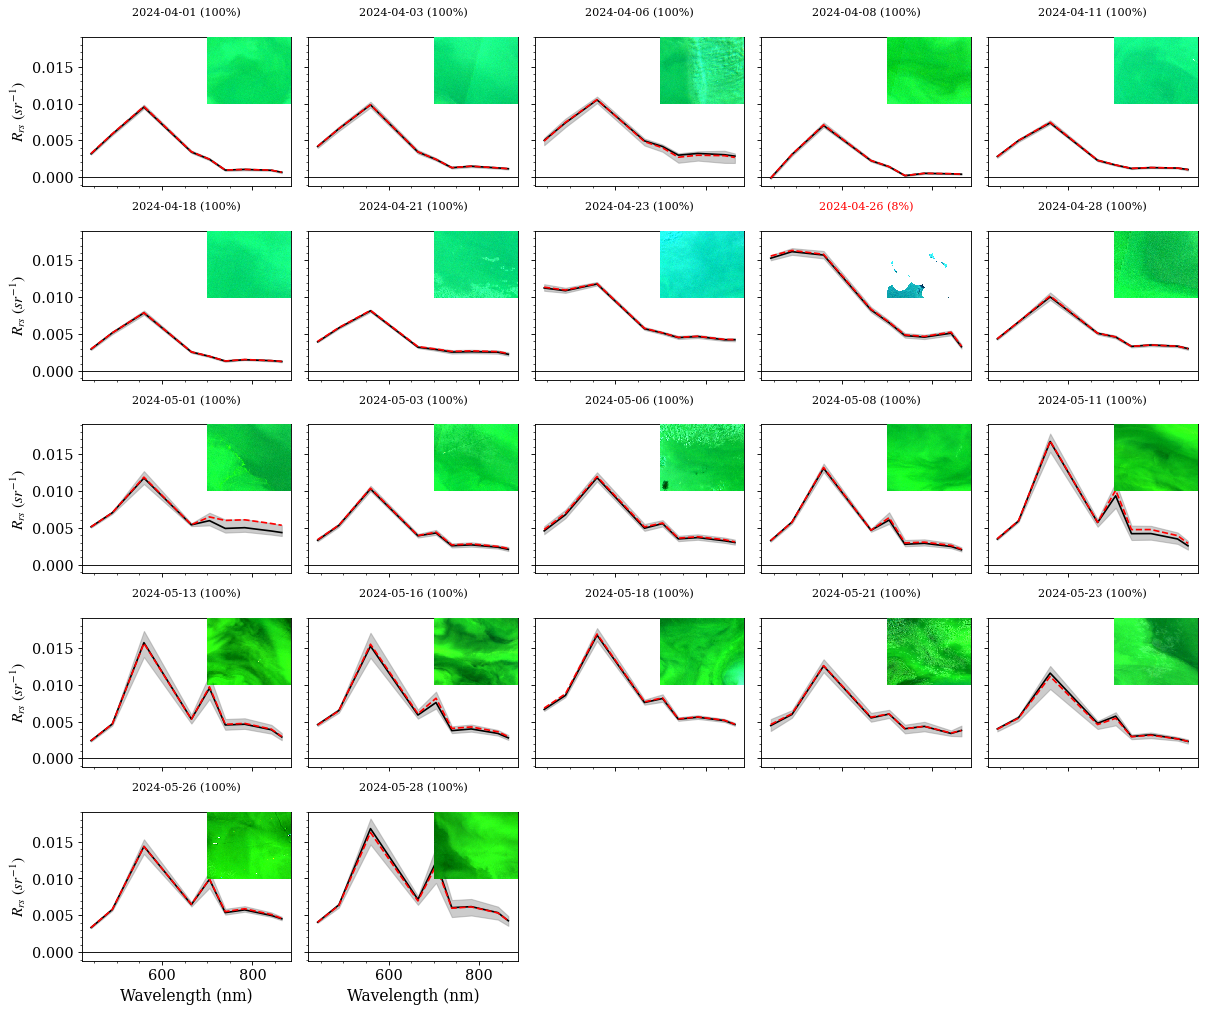

In [14]:
ncols = 5
nrows = int(np.ceil(stats.sizes['time'] / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=(ncols * 3.6, nrows * 3), sharex=True, sharey=True,
                        squeeze=False)
fig.subplots_adjust(hspace=0.3, wspace=0.08)
for ax in axs.flat:
    ax.set_axis_off()
for ax, time in zip(axs.flat, stats.time.values):
    s = stats.sel(time=time)
    ax.set_axis_on()
    ax.axhline(0, c='k', lw=0.8)
    ax.fill_between(s.wl, s.q25, s.q75, color='grey', alpha=0.4)
    ax.plot(s.wl, s['median'], c='k')
    ax.plot(s.wl, s['mean'], c='red', ls='--')
    ok = float(s.valid_fraction) >= 0.5
    ax.set_title(f'{pd.Timestamp(time):%Y-%m-%d} ({float(s.valid_fraction):.0%})', fontsize=10,
                 color='k' if ok else 'red')
    ax.minorticks_on()

    inset = ax.inset_axes([0.6, 0.55, 0.4, 0.45])
    Rrs.sel(time=time, wl=[665, 560, 490]).plot.imshow(ax=inset, rgb='wl', robust=True)
    inset.set_axis_off()
    inset.set_title('')
for ax in axs[:, 0]:
    ax.set_ylabel(r'$R_{rs}\ (sr^{-1})$')
for ax in axs[-1]:
    ax.set_xlabel('Wavelength (nm)')